In [36]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import re

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# Add this at start:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# If it prints "cpu" → need GPU!

Using: cuda


In [39]:
# step:1 Load dataset

df = pd.read_csv("/content/drive/MyDrive/IMDB Dataset.csv")
print(df.head())

#Dataset contains: review (text)

# sentiment (positive / negative)


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [40]:
# step:2 Convert sentiment to binary labels

df=df.rename(columns={"sentiment":"Label"})
df["Label"]=df["Label"].map({"positive":1,"negative":0})


In [41]:
df.head()

,review,Label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [42]:
# step:3 Clean the text data

#Regular Expression Substitute(re.sub) - A function to find and replace text patterns

def clean_text(review):
    review=review.lower()                           # convert to lowercase
    review=re.sub(r"<.*?>","",review)
    review=re.sub(r"[^a-zA-Z0-9\s]","",review)      # remove punctuation
    return review
df["review"]=df["review"].apply(clean_text)
print(df.head())

                                              review  Label
0  one of the other reviewers has mentioned that ...      1
1  a wonderful little production the filming tech...      1
2  i thought this was a wonderful way to spend ti...      1
3  basically theres a family where a little boy j...      0
4  petter matteis love in the time of money is a ...      1


In [43]:
df.drop_duplicates(inplace=True)

In [44]:
# step:4 Train-test split

train_df,test_df=train_test_split(df,test_size=0.2,random_state=42)
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 39664, Test size: 9916


In [45]:
# step:5 Tokenization

def tokenize(text):
    return text.split()
train_tokens=[tokenize(x) for x in train_df["review"]]
test_tokens=[tokenize(x) for x in test_df["review"]]

print(train_tokens[:2])
print(train_df.shape)


[['this', 'movie', 'has', 'all', 'the', 'ingredients', 'of', 'a', 'great', 'horror', 'story', 'and', 'loses', 'it', 'in', 'the', 'last', 'half', 'few', 'movies', 'can', 'actually', 'give', 'me', 'chill', 'bumps', 'this', 'one', 'did', 'few', 'horror', 'movie', 'give', 'me', 'a', 'sense', 'of', 'dread', 'this', 'one', 'did', 'it', 'kept', 'me', 'guessing', 'i', 'cared', 'about', 'the', 'story', 'i', 'cared', 'about', 'the', 'characters', 'the', 'acting', 'was', 'decent', 'unfortunately', 'about', 'half', 'way', 'through', 'the', 'movie', 'the', 'story', 'just', 'doesnt', 'have', 'many', 'good', 'directions', 'it', 'can', 'go', 'it', 'becomes', 'evident', 'that', 'everything', 'cool', 'about', 'the', 'plot', 'is', 'going', 'to', 'selfdestruct', 'it', 'does', 'what', 'builds', 'in', 'the', 'first', 'half', 'as', 'a', 'great', 'horror', 'concept', 'shifts', 'away', 'from', 'horror', 'and', 'towards', 'the', 'absurd', 'a', 'plausible', 'fear', 'turns', 'into', 'a', 'series', 'of', 'implausi

In [46]:
# step:6 Build vocabulary

all_tokens = []
for tokens in train_tokens:
    all_tokens.extend(tokens)   #  We took all the words from all the reviews and dumped them into one giant list.
print(f"total words in the dataset are: {len(all_tokens)}")

counter=Counter(all_tokens)      #The counter object now holds a frequency map: as example Counter({'i': 2, 'love': 2, 'this': 2, 'movie': 2, 'is': 1, 'great': 1, 'python': 1})
print(counter.most_common(10))

vocab={"<pad>":0,"<unk>":1}
for word in counter:
    vocab[word]=len(vocab)
vocab_size=len(vocab)

print(f"unique words are now: {vocab_size}")




total words in the dataset are: 9008093
[('the', 517972), ('a', 254517), ('and', 254244), ('of', 229705), ('to', 211928), ('is', 167553), ('in', 145983), ('it', 120371), ('i', 115795), ('this', 115625)]
unique words are now: 192766


### note 1:

We create official dictionary, called vocab. We start by adding two special words that aren't actually in the reviews.

"pad": Stands for "padding". Later, to make all reviews the same length for the model, we'll add this token to the end of shorter reviews.

"unk": Stands for "unknown". When the model sees a new word during testing that wasn't in the training data, it will use this token.


**len(vocab)**

First word (let's say the loop picks 'i'): 

len(vocab) is currently 2 (because it has 2 items, pad and unk). So, we do vocab['i'] = 2.

vocab now: {'<pad>': 0, '<unk>': 1, 'i': 2}

Second word (loop picks 'love'): Now len(vocab) is 3. So, vocab['love'] = 3.

vocab now: {'<pad>': 0, '<unk>': 1, 'i': 2, 'love': 3}

In [47]:
# step:7 Convert text to numbers

def text_to_indices(tokens):
    return [vocab.get(word,vocab["<unk>"]) for word in tokens]   #For each word in a review: Look up the word in vocab dictionary

#If found → return its number (ID)
#If not found → return <unk> token ID (usually 1)

train_indices=[text_to_indices(tokens) for tokens in train_tokens]
test_indices=[text_to_indices(tokens) for tokens in test_tokens]

print(train_indices[:2])

[[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 6, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 2, 27, 28, 19, 11, 3, 23, 24, 9, 29, 8, 30, 2, 27, 28, 15, 31, 24, 32, 33, 34, 35, 6, 12, 33, 34, 35, 6, 36, 6, 37, 38, 39, 40, 35, 18, 41, 42, 6, 3, 6, 12, 43, 44, 45, 46, 47, 48, 15, 21, 49, 15, 50, 51, 52, 53, 54, 35, 6, 55, 56, 57, 58, 59, 15, 60, 61, 62, 16, 6, 63, 18, 64, 9, 10, 11, 65, 66, 67, 68, 11, 13, 69, 6, 70, 9, 71, 72, 73, 74, 9, 75, 8, 76, 77, 68, 6, 36, 6, 12, 78, 79, 80, 81, 2, 3, 82, 83, 84, 56, 27, 85, 86, 52, 87, 88, 89, 9, 90, 6, 3, 91, 47, 92, 89, 9, 90, 2, 3, 56, 93, 94, 16, 6, 95, 43, 96, 97, 58, 98, 99, 2, 56, 100, 101, 64, 9, 3, 58, 102, 103, 104, 105, 9, 3, 106, 107, 58, 108], [2, 109, 110, 56, 105, 6, 100, 13, 111, 112, 113, 6, 114, 33, 115, 79, 6, 116, 52, 117, 109, 56, 118, 119, 120, 121, 13, 122, 123, 124, 125, 2, 9, 126, 89, 6, 127, 127, 127, 128, 129, 130, 131, 132, 6, 133, 134, 135, 136, 137, 138, 139, 140, 13, 141, 137, 142, 143, 144, 145, 146, 147, 148, 

In [48]:
# step:8 Create Dataset class

#PyTorch needs a standard way to access your data in batches."Dataset class = Organizes your data with numbers (0 to 40,000) so PyTorch can easily grab any sample and make batches!"



class IMDBDataset(Dataset):                # Create a custom dataset class
    def __init__(self,sequences,labels):   # Constructor - runs once when creating dataset
        self.sequences=sequences           # Store all reviews (as numbers)
        self.labels=labels                 # Store all labels (0/1)
    # Why? To keep data and labels together in one object 
    
    def __len__(self):                    # Tells PyTorch how many samples you have
        return len(self.sequences)       # Returns 40,000 (number of reviews)
    #Why? So DataLoader knows how many batches to create
   
    def __getitem__(self,idx):             # Gets one sample by its index number
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])
    
    # Why? So DataLoader can fetch specific samples when making batches
    # idx = 0 → returns first review and its label
    # idx = 5 → returns sixth review and its label

### note 2:

**Without Dataset class:**

You have 40,000 reviews and labels as Python lists

train_indices = [[2,3,4], [1,5,6], ...]  # 40,000 reviews

train_labels = [1, 0, 1, 0, ...]          # 40,000 labels

 To train with batch_size=64, you'd have to manually:

  - Loop through indices 0-63, 64-127, etc.
  
  - Convert each to tensor
  
  - Handle shuffling yourself

  - Track which samples you've used
  
  - MESSY and ERROR-PRONE!

**With Dataset class:**

PyTorch needs a standardized way to access your data when training in batches

Just 3 simple methods:

1. __init__: Store data

2. __len__: Tell total count

3. __getitem__: Give sample by index

Then PyTorch handles everything:

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
for batch in dataloader:        # PyTorch does all the work! 
    sequences, labels = batch   # Ready-to-use tensors!

Dataset class = A contract between data and PyTorch that tells PyTorch how to access your data, so it can automatically handle batching, shuffling, and tensor conversion during training!"



In [49]:
# step:9 Create DataLoader (Padding)

# DataLoader feeds data to your model in batches automatically.
# DataLoader - Creates batches

def collate_fn(batch):
    # batch is a list of tuples: [(seq1, label1), (seq2, label2), ...]  (32 items)
    
    sequences, labels = zip(*batch)  
    # zip(*batch) separates all sequences and all labels
    # sequences = (seq1, seq2, seq3, ...)  # 32 sequences of DIFFERENT lengths
    # labels = (label1, label2, label3, ...)  # 32 labels
    
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0)
    # PROBLEM: Sequences have different lengths!
    # Example: [2,3,4] and [1,5,6,7,8] can't be in same tensor
    # SOLUTION: Pad shorter sequences with 0 to match longest
    # padding_value=0 uses <pad> token
    # batch_first=True makes shape: (batch, seq_len)
    
    return padded_sequences, torch.tensor(labels)
    # Returns: (32 sequences padded to same length), (32 labels as tensor)

train_dataset = IMDBDataset(train_indices, train_df["Label"].values)
# Creates dataset with:
# - train_indices: 40,000 reviews as numbers
# - train_df["label"].values: 40,000 labels (0/1)

test_dataset = IMDBDataset(test_indices, test_df["Label"].values)
# Same for test: 10,000 reviews and labels

train_loader = DataLoader(
    train_dataset,     # Dataset with 40,000 reviews
    batch_size=32,     # Take 32 reviews at a time
    shuffle=True,      # Randomize order each epoch (prevents learning order)
    collate_fn=collate_fn  # Use our custom function to pad batches
)
# train_loader will yield 40,000/32 = 1250 batches per epoch

test_loader = DataLoader(
    test_dataset,      # Dataset with 10,000 reviews
    batch_size=32,     # Take 32 reviews at a time
    shuffle=False,     # Don't shuffle test data (consistent evaluation)
    collate_fn=collate_fn  # Same padding function
)
# test_loader will yield 10,000/32 = 313 batches



#### Without padding (can't make tensor!):
sequences = [[2,3,4], [1,5,6,7]]

torch.tensor(sequences)  # ERROR! Different lengths! ❌

#### With pad_sequence (automatic padding):

padded = pad_sequence(sequences, batch_first=True, 
padding_value=0)

Result:

tensor([
    [2, 3, 4, 0],  # Padded to length 4

    [1, 5, 6, 7]   # Original length 4
])  


**WITHOUT batch_first (default):**

output shape = (seq_len, batch)  # (5, 3)

**WITH batch_first=True:**

output shape = (batch, seq_len)  # (3, 5) ← More 
                  
          3 reviews  each of length 5

**Why padding_value=0?**

In our vocabulary:

vocab = {

    "<pad>": 0,  # Padding token has ID 0

    "<unk>": 1,

    "the": 2,
    ...
}

So padding with 0 means adding <pad> tokens.

pad_sequence automatically finds the longest sequence in batch and pads all others to same length using 0s - like stretching shorter ropes to match longest.


In [50]:
# step:10 Build LSTM Model

class SentimentLSTM(nn.Module):  # Creates a neural network class
                                 # nn.Module is PyTorch's base class for all models
                                 
  def __init__(self, vocab_size, embed_dim, hidden_size):
      
    super().__init__()  # Calls parent class constructor (required for PyTorch)
    #init Method - Building the Model Architecture
    # vocab_size = number of unique words (e.g., 20,000)
    # embed_dim = size of word vectors (e.g., 100)
    # hidden_size = LSTM memory size (e.g., 128)  
    
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    
    # What it does: Converts word indices to dense vectors
    # Input:  word index [2, 3, 5, 1]  (4 words)
    # Output: vectors    [[0.1,0.2,...], [0.3,0.4,...], ...]  (4 × embed_dim)
    # padding_idx=0: Tells model to ignore <pad> tokens (ID=0)
    
    self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)      # Reads words one by one, updating memory at each step
    
    # What it does:When you call nn.LSTM, PyTorch automatically implements ALL gates (Forget, Input, Output) internally. Processes sequence and maintains memory
    # Input shape:  (batch, seq_len, embed_dim)
    # Output shape: (batch, seq_len, hidden_size)
    # batch_first=True: Input is (batch, seq, features) not (seq, batch, features)
    # Reads words one by one, remembers context
    
    # PyTorch creates ALL these components internally:
    # - Forget gate: f_t = σ(W_f · [h_{t-1}, x_t] + b_f)
    # - Input gate:  i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
    # - Candidate:   c̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c)
    # - Output gate: o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
    # - Cell update: c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t
    # - Hidden:      h_t = o_t ⊙ tanh(c_t)
    
        
    self.fc = nn.Linear(hidden_size, 1)                #Takes final memory and makes a single decision!
    
    # What it does: Converts LSTM memory to single score
    # Input shape:  (batch, hidden_size)
    # Output shape: (batch, 1)  # Single number per review
    # Analogy: Takes final understanding and makes decision

  def forward(self,x): 
  
      # x shape: (batch_size, sequence_length)
      # Example: (32, 200) - 32 reviews, each with 200 words
      # Each number is a word index (e.g., 2 for "the", 3 for "movie")
      
      x = self.embedding(x)
      
      # BEFORE: x = [[2, 3, 5, 1, ...], [4, 2, 6, 7, ...]]  # Word indices
      #         Shape: (32, 200)

      # AFTER: x = 3D tensor of word vectors
      #        Shape: (32, 200, 100)
      #        32 reviews, each 200 words, each word represented by 100 numbers
      
      out, (h_n, c_n) = self.lstm(x)
      
      # Input: x shape (32, 200, 100)
      # Outputs:
      # out: ALL hidden states at EVERY time step
      #      Shape: (32, 200, 128)
      #      Each of 200 words now has 128 memories

      # h_n: FINAL hidden state (last time step)
      #      Shape: (1, 32, 128)  
      #      [num_layers, batch, hidden_size]

      # c_n: FINAL cell state
      #      Shape: (1, 32, 128)
      
      out = h_n[-1]
      
      # h_n shape: (1, 32, 128)
      # h_n[-1] takes the LAST layer's hidden state
      # Output shape: (32, 128)

      # BEFORE: We had memories for ALL 200 words
      # AFTER: Only keep the FINAL understanding after reading entire review
      # Analogy: After reading whole book, you remember the summary
      # You don't need to remember every word, just the final conclusion!
      
      out = self.fc(out)
      
# Input: (32, 128) - 32 reviews, each with 128 memories
# Output: (32, 1) - 32 reviews, each with 1 score

# Linear layer calculation for one review:
# memories = [0.2, 0.7, 0.4, 0.8, ...] (128 numbers)
# weights = [0.1, 0.3, 0.2, 0.4, ...] (128 weights)
# bias = 0.2
# score = (0.2×0.1 + 0.7×0.3 + 0.4×0.2 + 0.8×0.4 + ...) + 0.2
#       = 0.84 (example)
# This converts 128 memories into ONE decision score!

      return torch.sigmoid(out).squeeze()
  
# Input: (32, 1) - raw scores
# After sigmoid: (32, 1) - probabilities between 0 and 1
# After squeeze(): (32,) - removes extra dimension

# Sigmoid formula: 1 / (1 + e^(-score))
# Score = 0.84 → sigmoid = 0.70 (70% positive)
# Score = -0.84 → sigmoid = 0.30 (30% positive = 70% negative)

model = SentimentLSTM(vocab_size, 100, 128)

# vocab_size: number of unique words (e.g., 20,000)
# 100: embedding dimension (each word = 100 numbers)
# 128: hidden size (LSTM memory size)

# This creates the model with:
# - Embedding layer: (20000 → 100)
# - LSTM layer: (100 → 128)
# - Linear layer: (128 → 1)   

Input at time t

x_t = [0.1, 0.2, 0.3]         # Current word embedding

h_prev = [0.4, 0.5]           # Previous hidden state

c_prev = [0.6, 0.7]           # Previous cell state

Inside LSTM (you don't see this, but it happens!):

**Forget gate:** "Should I forget old memory?"

f_t = sigmoid(0.1×W_f1 + 0.4×U_f1 + ...) = 0.9  # Keep 90%

**Input gate:** "Should I add new info?"

i_t = sigmoid(...) = 0.7  # Add 70% of new info

**Candidate:** "What new info to add?"
c_tilde = tanh(...) = 0.5  # New info value

**Update cell:** c_t = 0.9×0.6 + 0.7×0.5 = 0.54 + 0.35 = 0.89

**Output gate:** "What should I output?"

o_t = sigmoid(...) = 0.8  # Output 80% of cell

**Update hidden:**  h_t = 0.8 × tanh(0.89) = 0.8 × 0.71 = 0.57

You only see final h_t = 0.57, c_t = 0.89

All gate calculations hidden!



Let's say we have:

input = [0.5, 0.8, 0.2]        # 3 numbers (from LSTM)

linear = nn.Linear(3, 1)        # 3 inputs → 1 output

Inside linear layer (randomly initialized):

weights = [0.1, 0.3, 0.2]       # 3 weights (one per input)

bias = 0.4                       # 1 bias

Calculation:

output = (0.5×0.1 + 0.8×0.3 + 0.2×0.2) + 0.4

       = (0.05 + 0.24 + 0.04) + 0.4

       = 0.33 + 0.4 = 0.73

output = 0.73 (scaled value)

Need to inverse transform to get actual passengers:

original = scaler.inverse_transform([[0.73]])  # e.g., 152 passengers.

In [51]:
# step: 11 Training setup 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.BCELoss()

#Binary Cross Entropy Loss - measures how wrong predictions are
# Compares model output (probability) with true label (0 or 1)
# Higher loss = more wrong, lower loss = more right

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Adam = Smart optimizer that updates model weights
# model.parameters() = all weights in embedding, LSTM, linear layers
# lr=0.001 = learning rate (how big steps to take when updating)
# Goal: minimize the loss by adjusting weights

#Adam = "Adaptive Moment Estimation" this is fast and accuracy best then SGD 
#A smart algorithm that updates neural network weights to minimize loss!



In [56]:
# step: Train model

for epoch in range(10):   # One epoch = model sees ALL training data once
    model.train()
    total_loss = 0

    for sequences, labels in train_loader:     
    # Get one batch (32 reviews)
    # sequences: (32, seq_len) - batch of reviews
    # labels: (32,) - 0 or 1 for each review

        sequences = sequences.to(device)        # Move Data to GPU/CPU
        labels = labels.to(device).float() 

        optimizer.zero_grad()      # Reset gradients from previous batch
        
        #Forward Pass
        
        outputs = model(sequences) #outputs = model(sequences)  # Get predictions (probabilities)
        # outputs shape: (32,) - 32 probabilities

        loss = criterion(outputs, labels)    # Compares predictions with true labels
        
        # Backward Pass
        loss.backward()                      # Calculate gradients (how to improve)
        
        optimizer.step()               # Update weights using gradients
# weights = weights - learning_rate × gradients

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))     # Average loss for all batches in this epoch

Epoch: 1 Loss: 0.6104333340881333
Epoch: 2 Loss: 0.6047940687546807
Epoch: 3 Loss: 0.5997728918108248
Epoch: 4 Loss: 0.5970095709206596
Epoch: 5 Loss: 0.5793929471123603
Epoch: 6 Loss: 0.5023414601722072
Epoch: 7 Loss: 0.40401176339796474
Epoch: 8 Loss: 0.3642533128420191
Epoch: 9 Loss: 0.3208194914844728
Epoch: 10 Loss: 0.2842923392872176


In [57]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        outputs = model(sequences)
        preds = (outputs > 0.5).int()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8033481242436467


In [58]:
def predict(text):
    model.eval()
    text = clean_text(text)
    tokens = tokenize(text)
    indices = text_to_indices(tokens)
    tensor = torch.tensor(indices).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
    return "Positive" if output.item() > 0.5 else "Negative"

print(predict("This movie was amazing and fantastic"))
print(predict("Worst movie I have ever seen"))

Positive
Negative


 #### Flow summary:

 Text → Clean → Tokenize → Numbers → Embedding → LSTM → Hidden State → Linear → Sigmoid → Prediction

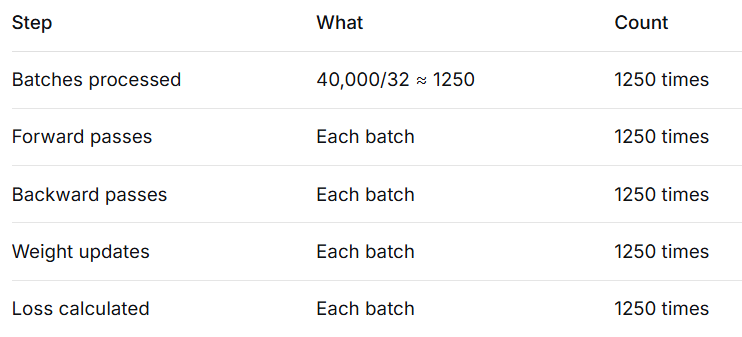